In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the capex sheet
df_capex = pd.read_excel("toy_results.xlsx", sheet_name="capex")

print(df_capex.head())

    technology                         item      category  investment
0  aquathermal             Water Collectors  heat sources     26250.0
1  aquathermal  Water Pipes, fittings, etc.  heat sources     12750.0
2  aquathermal                    E-Cabling  heat sources      3750.0
3  aquathermal               Source-HP Pump  heat sources    393925.0
4  aquathermal                   Pump House  heat sources     25000.0


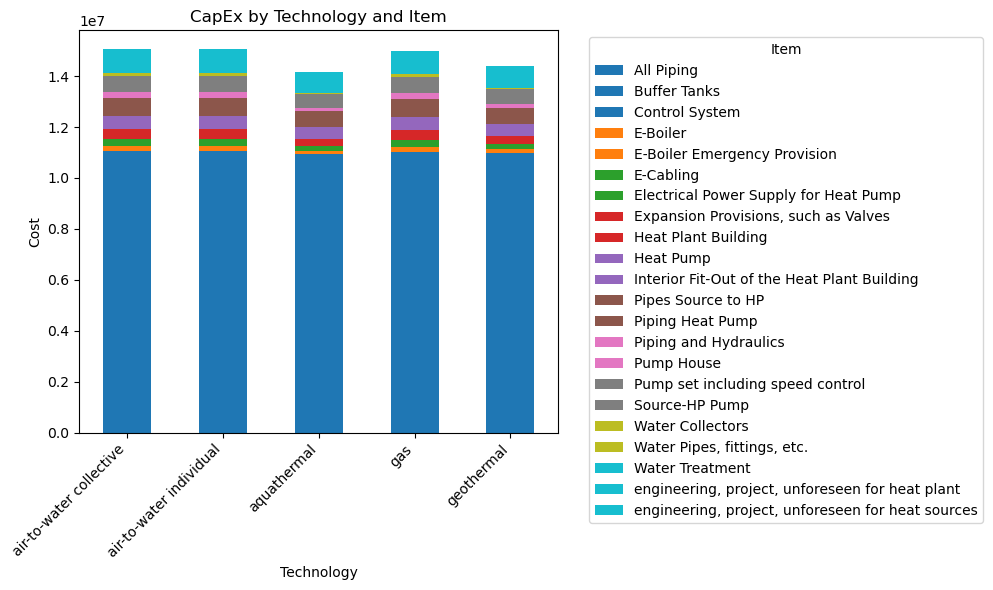

In [13]:
# Pivot: x-axis = technology, stacked segments = item, values = cost
pivot = df_capex.pivot_table(index="technology", columns="item", values="investment", aggfunc="sum")

# Plot stacked bar chart
plt.style.use("default")
ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab10"
)

ax.set_title("CapEx by Technology and Item")
ax.set_xlabel("Technology")
ax.set_ylabel("Cost")
ax.legend(title="Item", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

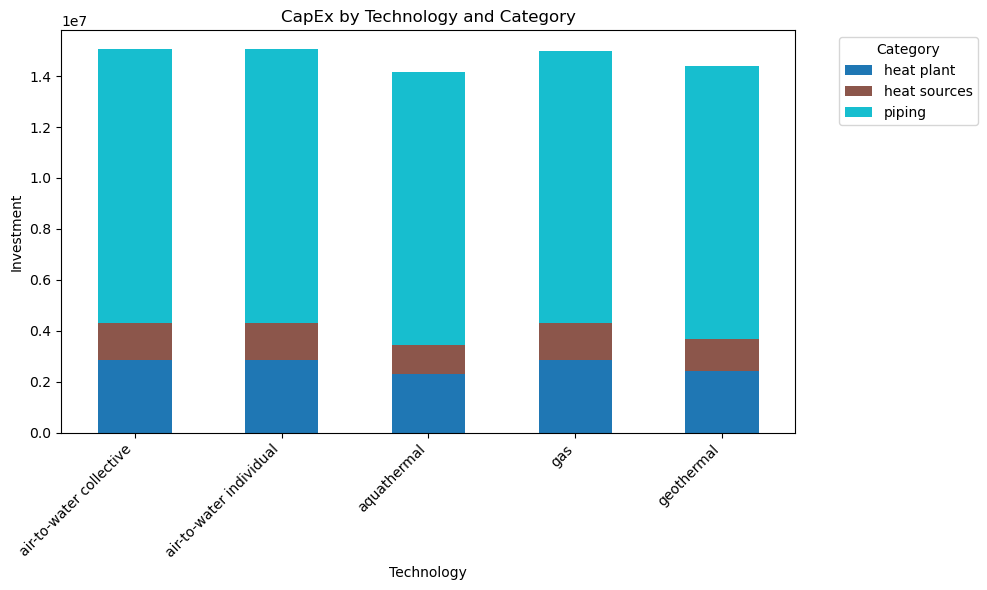

In [23]:
pivot_category = df_capex.pivot_table(index="technology", columns="category", values="investment", aggfunc="sum").fillna(0)

plt.style.use("default")
ax = pivot_category.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab10"
)

ax.set_title("CapEx by Technology and Category")
ax.set_xlabel("Technology")
ax.set_ylabel("Investment")
ax.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

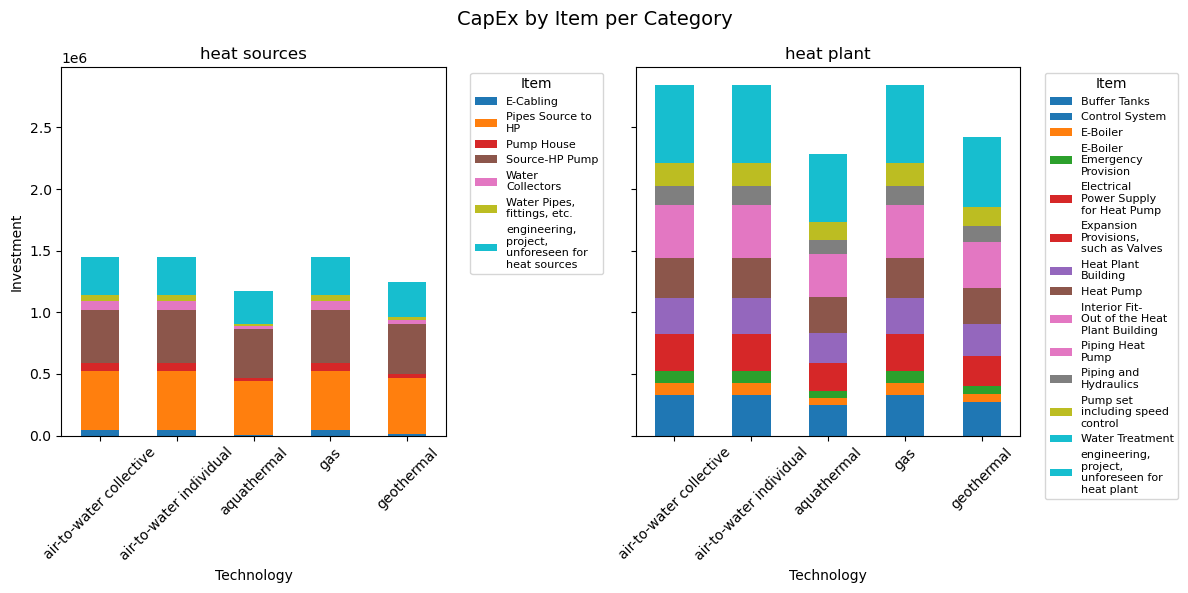

In [32]:
import textwrap

df_filtered = df_capex[df_capex["category"] != "piping"]
categories = df_filtered["category"].unique()  # moved here

fig, axes = plt.subplots(1, len(categories), figsize=(6 * len(categories), 6), sharey=True)

if len(categories) == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    subset = df_filtered[df_filtered["category"] == cat]
    pivot = subset.pivot_table(index="technology", columns="item", values="investment", aggfunc="sum").fillna(0)

    pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        colormap="tab10",
        legend=True
    )

    ax.set_title(cat)
    ax.set_xlabel("Technology")
    ax.tick_params(axis="x", rotation=45)
    handles, labels = ax.get_legend_handles_labels()
    wrapped_labels = [textwrap.fill(label, width=15) for label in labels]
    ax.legend(handles, wrapped_labels, title="Item", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

axes[0].set_ylabel("Investment")
fig.suptitle("CapEx by Item per Category", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Load the capex sheet
df_toc = pd.read_excel("toy_results.xlsx", sheet_name="toc")

print(df_toc.head())

                       id      technology     toc location
0     Aquathermal_Enspijk     Aquathermal  104000  Enspijk
1      Geothermal_Enspijk      Geothermal  107000  Enspijk
2  Air-Water Ind._Enspijk  Air-Water Ind.   98000  Enspijk
3  Air-Water Col._Enspijk  Air-Water Col.   97000  Enspijk
4             Gas_Enspijk             Gas   79000  Enspijk


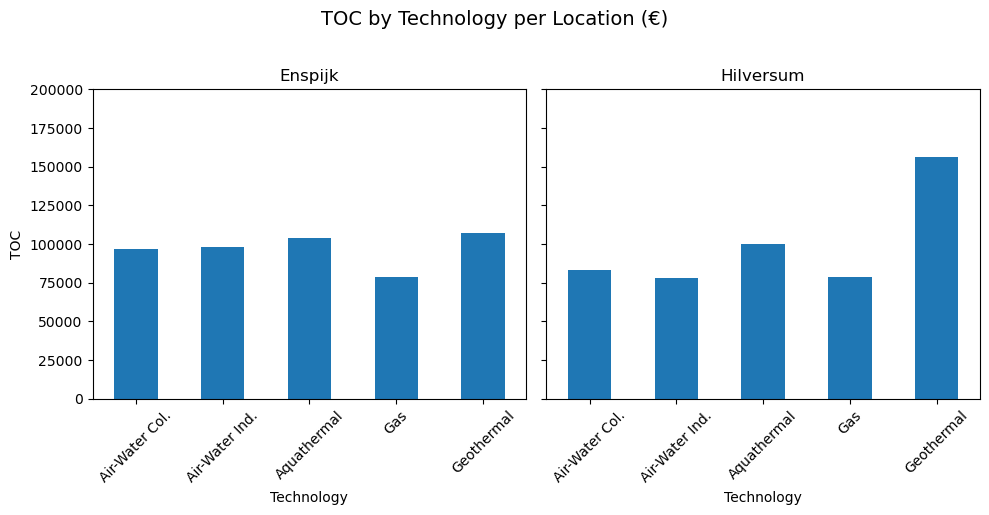

In [15]:
locations = df_toc["location"].unique()
n = len(locations)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=True)

if n == 1:
    axes = [axes]

for ax, loc in zip(axes, locations):
    subset = df_toc[df_toc["location"] == loc]
    pivot = subset.pivot_table(index="technology", values="toc", aggfunc="sum")

    pivot.plot(
        kind="bar",
        ax=ax,
        colormap="tab10",
        legend=False
    )

    ax.set_title(loc)
    ax.set_xlabel("Technology")
    ax.set_ylim(0, 200000)
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("TOC")
fig.suptitle("TOC by Technology per Location (\u20ac)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
## chart above is relevant to sensitivity analysis

In [17]:
## include TCO and tariff per tech side by side, per tech.

In [18]:
## box plot, tcos for different sensitivity scenarios, columns are sensitivity techs, highlight as baseline

In [19]:
## dupe for tariff

In [20]:
## toy array of sensitivity results as percentage

# import pandas as pd
# import numpy as np
#
# np.random.seed(42)
#
# technologies = [f"Tech{i}" for i in range(1, 6)]
# n_params = 10
#
# rows = {}
#
# # Baseline row with all zeros
# rows["Baseline"] = np.zeros(5)
#
# for p in range(1, n_params + 1):
#     rows[f"P{p}U"] = np.random.uniform(0, 1, 5)
#     rows[f"P{p}L"] = np.random.uniform(-1, 0, 5)
#
# df_params = pd.DataFrame(rows, index=technologies).T
#
# print(df_params)

In [21]:
import pandas as pd
import numpy as np

np.random.seed(25)

technologies = [f"Tech{i}" for i in range(1, 6)]
technologies = ["AWHP Individual", "AWHP Collective", "Geothermal", "Aquathermal", "Natural Gas"]
n_params = 10

rows = {}

# Baseline row with all 40s
rows["Baseline"] = np.random.uniform(0, 80, 5)

for p in range(1, n_params + 1):
    rows[f"P{p}U"] = np.random.uniform(40, 80, 5)
    rows[f"P{p}L"] = np.random.uniform(0, 40, 5)

df_params = pd.DataFrame(rows, index=technologies).T

print(df_params)

          AWHP Individual  AWHP Collective  Geothermal  Aquathermal  \
Baseline        69.609931        46.582154   22.307115    14.872899   
P1U             44.695022        67.398750   57.504442    62.249173   
P1L             16.094629         4.521628   17.881234    23.417805   
P2U             60.828752        53.042045   67.967450    54.655782   
P2L             19.253718        20.660092   15.321925    39.901636   
P3U             62.362131        41.377991   68.797201    56.840142   
P3L             11.268030        36.010974   26.784491    18.242750   
P4U             61.032759        62.369682   69.811353    73.133850   
P4L              3.085613        25.794483   12.370303    20.970149   
P5U             75.328038        51.817276   60.495040    43.548097   
P5L              5.296822        30.659433    3.069690    13.241753   
P6U             60.368523        66.205846   64.084814    68.762182   
P6L             15.861665        33.005559   28.502070     3.917486   
P7U   

/var/folders/_q/_8j7xmxj1knfd24nmfn58vf80000gn/T/ipykernel_66750/1501100130.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


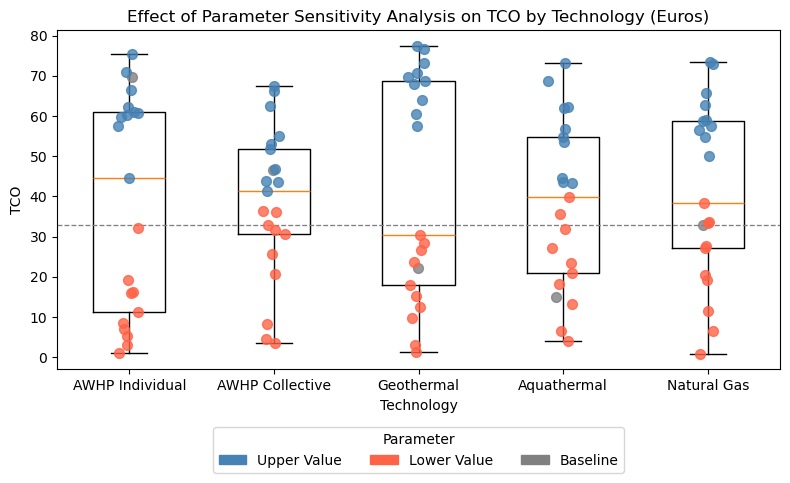

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

color_map = {}
for row in df_params.index:
    if row == "Baseline":
        color_map[row] = "gray"
    elif row.endswith("U"):
        color_map[row] = "steelblue"
    elif row.endswith("L"):
        color_map[row] = "tomato"

plt.style.use("default")
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    [df_params[col].values for col in df_params.columns],
    labels=df_params.columns,
    showfliers=False
)

np.random.seed(42)
for i, col in enumerate(df_params.columns, start=1):
    for row in df_params.index:
        y = df_params.loc[row, col]
        x = np.random.normal(i, 0.04)
        ax.scatter(x, y, color=color_map[row], alpha=0.8, zorder=3, s=50)

## baseline for natural gas as benchmark
ax.axhline(df_params.loc["Baseline", "Natural Gas"], color="gray", linestyle="--", linewidth=0.95)

ax.set_title("Effect of Parameter Sensitivity Analysis on TCO by Technology (Euros)")
ax.set_xlabel("Technology")
ax.set_ylabel("TCO")
# ax.axhline(40, color="gray", linestyle="--", linewidth=0.8)  # updated to baseline=40

legend_handles = [
    mpatches.Patch(color="steelblue", label="Upper Value"),
    mpatches.Patch(color="tomato", label="Lower Value"),
    mpatches.Patch(color="gray", label="Baseline"),
]
ax.legend(handles=legend_handles, title="Parameter", loc="upper center",
          bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.tight_layout()
plt.show()